# Keypoint Training Pipeline Visualization

This notebook visualizes one random training sample through the same keypoint pipeline used in training:
1. original image
2. cropped player image (from COCO bbox)
3. letterbox-resized image
4. original keypoints
5. normalized/cropped keypoints
6. heatmap targets

## Setup

In [3]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.keypoint_dataset import TennisKeypointDataset
from preprocessing.pil_preprocessing import letterbox_resize
from train.keypoint_train import KeypointsToHeatmaps

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT_DIR = PROJECT_ROOT / "datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation"
ANNOTATION_DIR = "annotations"
IMAGE_SIZE = (128, 128)  # (height, width)
NUM_KEYPOINTS = 18
HEATMAP_SIGMA = 2.0

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {ROOT_DIR}")

Project root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection
Dataset root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation


## 1) Image Pipeline Stages

Random sample: original image → cropped image (bbox) → letterbox resized image.

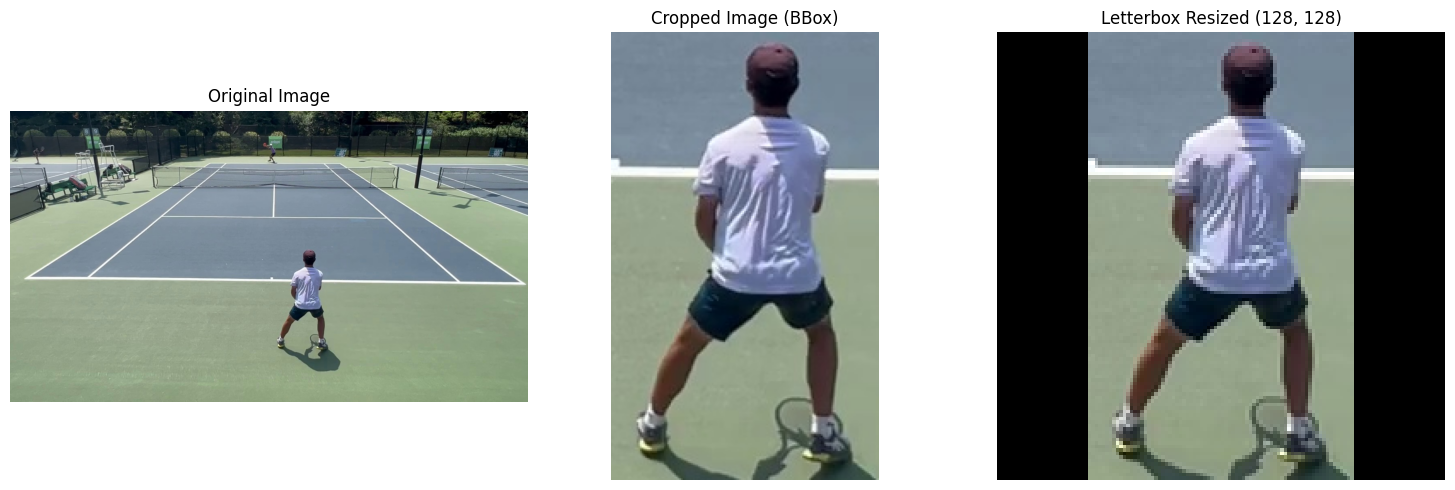

Sample index: 1309
Image path: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/datasets/orvile/tennis-player-actions-dataset/versions/1/Tennis Player Actions Dataset for Human Pose Estimation/images/ready_position/R_314.jpeg
BBox [x, y, w, h]: [645, 338, 157, 263]


In [4]:
dataset_for_visual = TennisKeypointDataset(
    root_dir=str(ROOT_DIR),
    annotation_dir=ANNOTATION_DIR,
    image_transform=None,
    keypoint_transform=None,
)

sample_idx = random.randrange(len(dataset_for_visual))
raw_sample = dataset_for_visual.data[sample_idx]

img_path = raw_sample["img_path"]
bbox = raw_sample["bbox"]
x, y, w, h = bbox

original_img = Image.open(img_path).convert("RGB")
cropped_img, normalized_keypoints_tensor = dataset_for_visual[sample_idx]
letterboxed_img = letterbox_resize(cropped_img.copy(), IMAGE_SIZE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cropped_img)
axes[1].set_title("Cropped Image (BBox)")
axes[1].axis("off")

axes[2].imshow(letterboxed_img)
axes[2].set_title(f"Letterbox Resized {IMAGE_SIZE}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Sample index: {sample_idx}")
print(f"Image path: {img_path}")
print(f"BBox [x, y, w, h]: {bbox}")

## 2) Keypoint Vector Stages

Original keypoints (full-image coordinates) → normalized cropped keypoints (bbox-local coordinates).

In [5]:
original_keypoints = np.array(raw_sample["keypoints"], dtype=np.float32).reshape(NUM_KEYPOINTS, 3)
normalized_keypoints = normalized_keypoints_tensor.numpy()

print("Original keypoint vector shape:", original_keypoints.shape)
print("Original keypoints (x, y, visibility):")
print(original_keypoints)

print("\nNormalized + cropped keypoint vector shape:", normalized_keypoints.shape)
print("Normalized keypoints (x_norm, y_norm, visibility):")
print(normalized_keypoints)

Original keypoint vector shape: (18, 3)
Original keypoints (x, y, visibility):
[[741. 370.   1.]
 [734. 363.   1.]
 [745. 364.   1.]
 [727. 371.   2.]
 [753. 371.   2.]
 [712. 399.   2.]
 [769. 401.   2.]
 [698. 449.   2.]
 [766. 444.   2.]
 [715. 463.   1.]
 [747. 434.   1.]
 [714. 480.   2.]
 [757. 479.   2.]
 [693. 521.   2.]
 [767. 515.   2.]
 [672. 563.   2.]
 [766. 570.   2.]
 [739. 384.   2.]]

Normalized + cropped keypoint vector shape: (18, 3)
Normalized keypoints (x_norm, y_norm, visibility):
[[0.611465   0.121673   1.        ]
 [0.566879   0.09505703 1.        ]
 [0.6369427  0.09885932 1.        ]
 [0.522293   0.12547529 2.        ]
 [0.6878981  0.12547529 2.        ]
 [0.42675158 0.23193917 2.        ]
 [0.7898089  0.23954372 2.        ]
 [0.3375796  0.42205322 2.        ]
 [0.77070063 0.40304184 2.        ]
 [0.44585988 0.47528517 1.        ]
 [0.6496815  0.36501902 1.        ]
 [0.43949044 0.53992397 2.        ]
 [0.7133758  0.53612167 2.        ]
 [0.3057325  0.6958175  

## 3) Heatmap Conversion Stage

Normalized cropped keypoints → heatmap target tensor used by keypoint training.

Heatmap tensor shape: (18, 128, 128)
Heatmap min/max: 0.0 0.9964461922645569


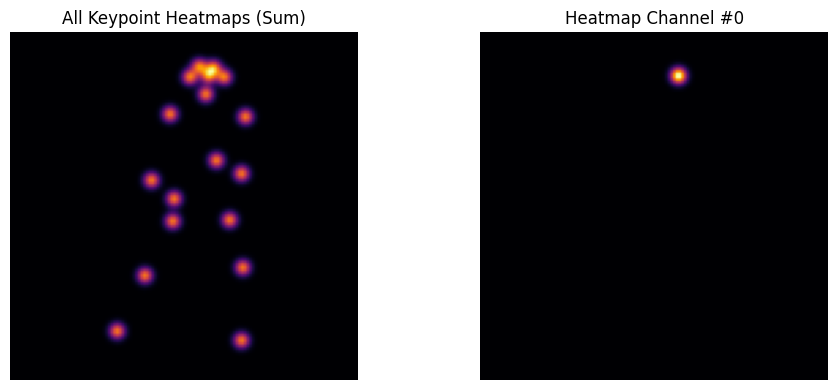

In [6]:
heatmap_transform = KeypointsToHeatmaps(
    out_size=IMAGE_SIZE,
    num_keypoints=NUM_KEYPOINTS,
    sigma=HEATMAP_SIGMA,
)

heatmaps = heatmap_transform(normalized_keypoints, float(w), float(h))

print("Heatmap tensor shape:", heatmaps.shape)
print("Heatmap min/max:", float(heatmaps.min()), float(heatmaps.max()))

visible_idxs = np.where(normalized_keypoints[:, 2] > 0)[0]
example_kp_idx = int(visible_idxs[0]) if len(visible_idxs) > 0 else 0

summed_heatmap = heatmaps.sum(axis=0)
example_heatmap = heatmaps[example_kp_idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(summed_heatmap, cmap="inferno")
axes[0].set_title("All Keypoint Heatmaps (Sum)")
axes[0].axis("off")

axes[1].imshow(example_heatmap, cmap="inferno")
axes[1].set_title(f"Heatmap Channel #{example_kp_idx}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 4) Letterbox Image + Heatmap Views

This section shows:
1) the letterbox-resized image next to the summed keypoint heatmap, and
2) an overlay view of the heatmap on top of the letterbox image.

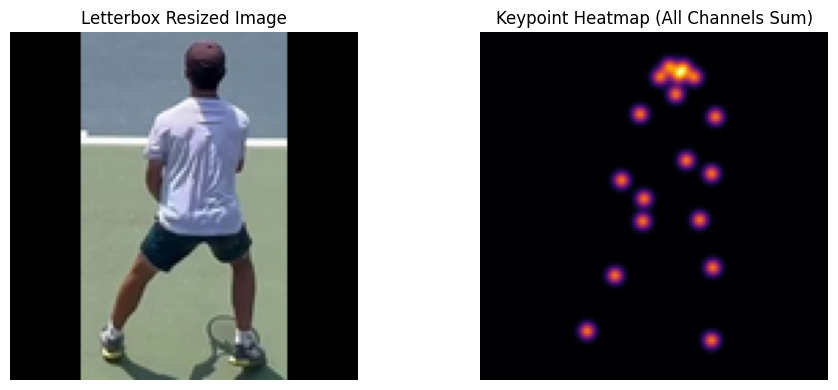

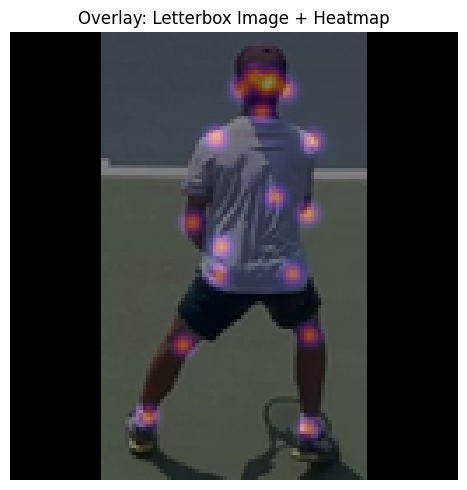

In [7]:
heatmap_overlay = summed_heatmap
letterboxed_np = np.array(letterboxed_img)

# View 1: side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(letterboxed_img)
axes[0].set_title("Letterbox Resized Image")
axes[0].axis("off")

axes[1].imshow(heatmap_overlay, cmap="inferno")
axes[1].set_title("Keypoint Heatmap (All Channels Sum)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# View 2: overlay
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(letterboxed_np)
ax.imshow(heatmap_overlay, cmap="inferno", alpha=0.5)
ax.set_title("Overlay: Letterbox Image + Heatmap")
ax.axis("off")

plt.tight_layout()
plt.show()

## 5) Letterbox Image + Normalized Keypoint Points

This plot overlays the normalized keypoint vector points on the letterbox-resized image.

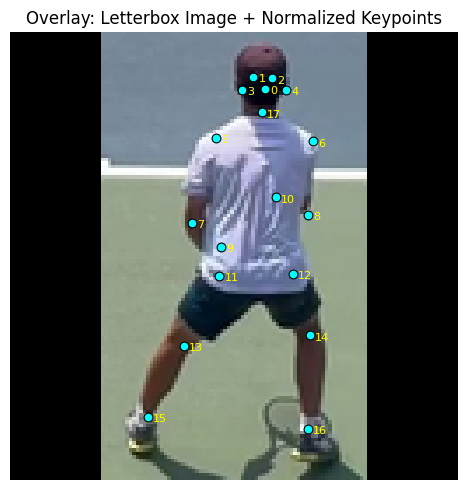

In [8]:
out_h, out_w = IMAGE_SIZE
bbox_w = float(w)
bbox_h = float(h)

scale = min(out_w / bbox_w, out_h / bbox_h)
resized_w = bbox_w * scale
resized_h = bbox_h * scale
pad_x = (out_w - resized_w) / 2.0
pad_y = (out_h - resized_h) / 2.0

kp = normalized_keypoints.copy()
visible_mask = kp[:, 2] > 0

x_crop = np.clip(kp[:, 0], 0.0, 1.0) * bbox_w
y_crop = np.clip(kp[:, 1], 0.0, 1.0) * bbox_h
x_letterbox = x_crop * scale + pad_x
y_letterbox = y_crop * scale + pad_y

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(letterboxed_img)
ax.scatter(
    x_letterbox[visible_mask],
    y_letterbox[visible_mask],
    c="cyan",
    s=40,
    edgecolors="black",
    linewidths=0.8,
)

for i in np.where(visible_mask)[0]:
    ax.text(x_letterbox[i] + 1.5, y_letterbox[i] + 1.5, str(i), color="yellow", fontsize=8)

ax.set_title("Overlay: Letterbox Image + Normalized Keypoints")
ax.axis("off")
plt.tight_layout()
plt.show()

## 6) Inference with Exported Best Model (Logits -> Probabilities)

The trained model now outputs **logits** (for `BCEWithLogitsLoss`).
This section converts logits to probabilities with sigmoid for visualization and diagnostics.

/var/folders/3k/zs813cfd5_36pyy2p9xmz4_80000gn/T/ipykernel_88463/561012007.py:27: RuntimeWarning: overflow encountered in exp
  pred_probs = 1.0 / (1.0 + np.exp(-pred_logits))


Loaded model from: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/keypoint_best_state_dict.pt
Predicted logits shape: (18, 128, 128)
Logits min/max: -184.6101531982422 6.703865051269531
Probability min/max: 0.0 0.9987753033638

--- Predicted Probability Heatmap Channel 0 ---
[[0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.
  0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.
  0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.       0.
  0.000001 0.       0.000008 0.000001 0.00005  0.000009 0.000274 0.000054 0.000605 0.000152 0.000865 0.000154 0.000551 0.000083 0.000237 0.000023 0.00005

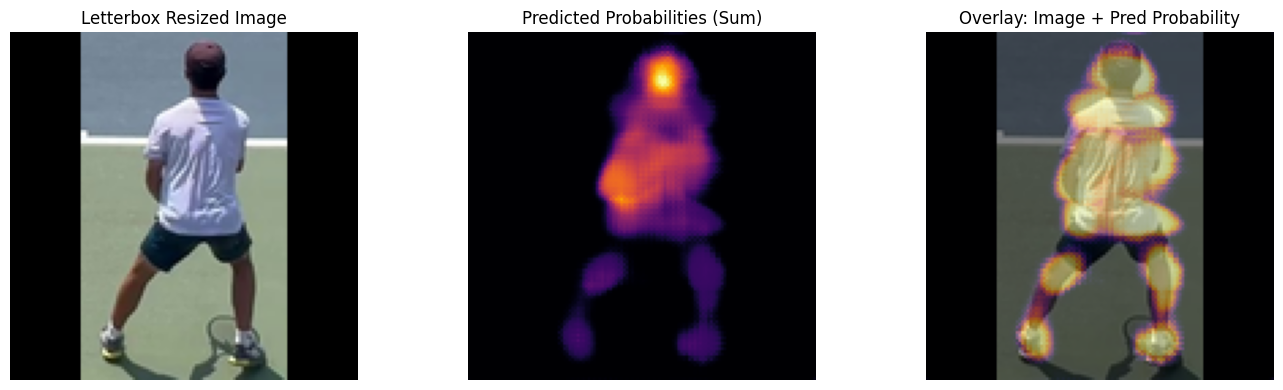

In [9]:
import torch
from models.keypoint_detection import KeypointDetectionModel

export_model_path = PROJECT_ROOT / "exports" / "keypoint_best_state_dict.pt"
if not export_model_path.exists():
    raise FileNotFoundError(f"Exported model not found: {export_model_path}")

checkpoint = torch.load(export_model_path, map_location="cpu")

if isinstance(checkpoint, dict) and "model_state" in checkpoint:
    state_dict = checkpoint["model_state"]
elif isinstance(checkpoint, dict):
    state_dict = checkpoint
else:
    raise ValueError("Unsupported exported model format. Expected state_dict or dict with 'model_state'.")

model_infer = KeypointDetectionModel(num_keypoints=NUM_KEYPOINTS)
model_infer.load_state_dict(state_dict)
model_infer.eval()

img_tensor = torch.from_numpy(np.array(letterboxed_img)).float() / 255.0
img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)

with torch.no_grad():
    pred_logits = model_infer(img_tensor).squeeze(0).cpu().numpy()  # (K, H, W)

pred_probs = 1.0 / (1.0 + np.exp(-pred_logits))
pred_heatmap_sum = pred_probs.sum(axis=0)
pred_heatmap_max = pred_probs.max(axis=0)

print(f"Loaded model from: {export_model_path}")
print("Predicted logits shape:", pred_logits.shape)
print("Logits min/max:", float(pred_logits.min()), float(pred_logits.max()))
print("Probability min/max:", float(pred_probs.min()), float(pred_probs.max()))

# Print predicted probabilities one channel at a time
old_opts = np.get_printoptions()
np.set_printoptions(precision=6, suppress=True, threshold=np.inf, linewidth=200)
for channel_idx in range(pred_probs.shape[0]):
    print(f"\n--- Predicted Probability Heatmap Channel {channel_idx} ---")
    print(pred_probs[channel_idx])
np.set_printoptions(**old_opts)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(letterboxed_img)
axes[0].set_title("Letterbox Resized Image")
axes[0].axis("off")

axes[1].imshow(pred_heatmap_sum, cmap="inferno")
axes[1].set_title("Predicted Probabilities (Sum)")
axes[1].axis("off")

axes[2].imshow(letterboxed_img)
axes[2].imshow(pred_heatmap_max, cmap="inferno", alpha=0.5)
axes[2].set_title("Overlay: Image + Pred Probability")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 7) Channel-Wise Heatmap Diagnostics (Probability Space)

Compares **predicted probabilities** vs **target heatmaps** channel-by-channel to detect saturation/collapse.

In [10]:
def channel_stats(arr: np.ndarray):
    return {
        "min": float(arr.min()),
        "max": float(arr.max()),
        "mean": float(arr.mean()),
        "std": float(arr.std()),
        "near_zero_frac": float((arr <= 1e-6).mean()),
        "near_one_frac": float((arr >= 1.0 - 1e-6).mean()),
    }

if pred_probs.shape != heatmaps.shape:
    raise ValueError(
        f"Shape mismatch: pred_probs {pred_probs.shape} vs target heatmaps {heatmaps.shape}. "
        "Run earlier cells with matching IMAGE_SIZE/model settings."
    )

print("Channel-wise diagnostics (Predicted Probabilities vs Target)")
print("=" * 120)
header = (
    f"{'Ch':>2} | {'Pred min':>9} {'Pred max':>9} {'Pred mean':>10} {'Pred std':>10} {'Pred ~0%':>9} {'Pred ~1%':>9}"
    f" || {'Tgt min':>9} {'Tgt max':>9} {'Tgt mean':>10} {'Tgt std':>10} {'Tgt ~0%':>9} {'Tgt ~1%':>9}"
)
print(header)
print("-" * len(header))

for ch in range(pred_probs.shape[0]):
    p = channel_stats(pred_probs[ch])
    t = channel_stats(heatmaps[ch])
    print(
        f"{ch:2d} | "
        f"{p['min']:9.6f} {p['max']:9.6f} {p['mean']:10.6f} {p['std']:10.6f} {100*p['near_zero_frac']:9.2f} {100*p['near_one_frac']:9.2f}"
        f" || {t['min']:9.6f} {t['max']:9.6f} {t['mean']:10.6f} {t['std']:10.6f} {100*t['near_zero_frac']:9.2f} {100*t['near_one_frac']:9.2f}"
    )

print("\nTip: channels with very high ~0% and tiny std are effectively flat/empty.")
print("Tip: channels with very high ~1% and tiny std are saturated high.")

Channel-wise diagnostics (Predicted Probabilities vs Target)
Ch |  Pred min  Pred max  Pred mean   Pred std  Pred ~0%  Pred ~1% ||   Tgt min   Tgt max   Tgt mean    Tgt std   Tgt ~0%   Tgt ~1%
-----------------------------------------------------------------------------------------------------------------------------------
 0 |  0.000000  0.986009   0.010122   0.086040     90.49      0.00 ||  0.000000  0.949503   0.001529   0.027652     98.97      0.00
 1 |  0.000000  0.983908   0.009406   0.081666     86.56      0.00 ||  0.000000  0.994994   0.001531   0.027652     98.97      0.00
 2 |  0.000000  0.994584   0.010335   0.087077     86.40      0.00 ||  0.000000  0.959001   0.001529   0.027652     98.97      0.00
 3 |  0.000000  0.976769   0.009306   0.079492     89.50      0.00 ||  0.000000  0.988608   0.001530   0.027652     98.97      0.00
 4 |  0.000000  0.995732   0.012280   0.097054     88.23      0.00 ||  0.000000  0.983703   0.001531   0.027652     98.97      0.00
 5 |  0.000000 

## 8) Evaluate Accuracy for a Specified `.pt` Model

This section evaluates keypoint localization accuracy over the dataset for a chosen model file.

- Starts with: `exports/keypoint_best_torchscript.pt`
- Also supports: state-dict `.pt` files (e.g., `exports/keypoint_best_state_dict.pt`)

In [11]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from models.keypoint_detection import KeypointDetectionModel

# Change this path to evaluate a different .pt model.
MODEL_PATH = PROJECT_ROOT / "exports" / "keypoint_best_torchscript.pt"
BATCH_SIZE = 16
NORMALIZED_DISTANCE_THRESHOLD = 0.05


def heatmap_keypoint_accuracy_torch(
    pred_heatmaps: torch.Tensor,
    target_heatmaps: torch.Tensor,
    normalized_distance_threshold: float = 0.05,
) -> float:
    if pred_heatmaps.shape != target_heatmaps.shape:
        raise ValueError(
            f"Shape mismatch: pred {tuple(pred_heatmaps.shape)} vs target {tuple(target_heatmaps.shape)}"
        )

    bsz, num_keypoints, heat_h, heat_w = pred_heatmaps.shape
    pred_flat = pred_heatmaps.view(bsz, num_keypoints, -1)
    target_flat = target_heatmaps.view(bsz, num_keypoints, -1)

    pred_idx = pred_flat.argmax(dim=-1)
    target_idx = target_flat.argmax(dim=-1)
    visible = target_flat.max(dim=-1).values > 0.0

    pred_x = (pred_idx % heat_w).float()
    pred_y = (pred_idx // heat_w).float()
    target_x = (target_idx % heat_w).float()
    target_y = (target_idx // heat_w).float()

    dx = (pred_x - target_x) / max(heat_w - 1, 1)
    dy = (pred_y - target_y) / max(heat_h - 1, 1)
    dist = torch.sqrt(dx * dx + dy * dy)

    correct = dist <= normalized_distance_threshold
    visible_count = int(visible.sum().item())
    if visible_count == 0:
        return 0.0

    correct_visible = int((correct & visible).sum().item())
    return correct_visible / visible_count


def load_model_for_eval(model_path: Path):
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    # Try TorchScript first (for keypoint_best_torchscript.pt)
    try:
        ts_model = torch.jit.load(str(model_path), map_location="cpu")
        ts_model.eval()
        return ts_model, "torchscript"
    except Exception:
        pass

    # Fallback: state_dict payload / raw state_dict
    checkpoint = torch.load(model_path, map_location="cpu")
    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        state_dict = checkpoint["model_state"]
    elif isinstance(checkpoint, dict):
        state_dict = checkpoint
    else:
        raise ValueError("Unsupported model format. Expected TorchScript or state_dict payload.")

    model = KeypointDetectionModel(num_keypoints=NUM_KEYPOINTS)
    model.load_state_dict(state_dict)
    model.eval()
    return model, "state_dict"


# Build eval dataset/loaders with same preprocessing as training
eval_image_transform = transforms.Compose([
    transforms.Lambda(lambda img: letterbox_resize(img, IMAGE_SIZE)),
    transforms.ToTensor(),
])
eval_keypoint_transform = KeypointsToHeatmaps(
    out_size=IMAGE_SIZE,
    num_keypoints=NUM_KEYPOINTS,
    sigma=HEATMAP_SIGMA,
)

eval_dataset = TennisKeypointDataset(
    root_dir=str(ROOT_DIR),
    annotation_dir=ANNOTATION_DIR,
    image_transform=eval_image_transform,
    keypoint_transform=eval_keypoint_transform,
)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)

model_eval, model_kind = load_model_for_eval(MODEL_PATH)

sample_images, sample_targets = next(iter(eval_loader))
with torch.no_grad():
    sample_logits = model_eval(sample_images)
if sample_logits.shape != sample_targets.shape:
    raise RuntimeError(
        f"Model output shape {tuple(sample_logits.shape)} does not match target shape {tuple(sample_targets.shape)}"
    )

acc_weighted_sum = 0.0
total_samples = 0

for images_batch, target_heatmaps_batch in eval_loader:
    with torch.no_grad():
        pred_logits_batch = model_eval(images_batch)
        pred_probs_batch = torch.sigmoid(pred_logits_batch)

    batch_acc = heatmap_keypoint_accuracy_torch(
        pred_probs_batch,
        target_heatmaps_batch,
        normalized_distance_threshold=NORMALIZED_DISTANCE_THRESHOLD,
    )

    batch_size = images_batch.size(0)
    acc_weighted_sum += batch_acc * batch_size
    total_samples += batch_size

final_acc = acc_weighted_sum / max(total_samples, 1)

print(f"Model path: {MODEL_PATH}")
print(f"Model type: {model_kind}")
print(f"Eval samples: {total_samples}")
print(f"Normalized distance threshold: {NORMALIZED_DISTANCE_THRESHOLD}")
print(f"Keypoint accuracy: {final_acc:.5f}")

Model path: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/keypoint_best_torchscript.pt
Model type: torchscript
Eval samples: 1994
Normalized distance threshold: 0.05
Keypoint accuracy: 0.77898
